In [1]:
import tenpy
import sys
sys.path.append('..')

# import importlib
# # importlib.reload(sys.modules['src'])
# importlib.reload(sys.modules['utils.bosonization'])
# importlib.reload(sys.modules['utils.slurmhelpers'])

from src.extendedHubbard import HubbardSpinDepV, run_idmrg
from utils.bosonization import ret_Vpm_crit, compute_Luttinger_parameter
from utils.slurmhelpers import ret_arr_for_taskid
import src.observables as observables
import utils.io as io
import logging 
logging.basicConfig(level=logging.INFO)
import time
import numpy as np
import matplotlib.pyplot as plt
import os
import re, glob
import pandas as pd
print(f"TeNPy version: {tenpy.__version__}")
DATA_ROOT = '../../data/iDMRG/'


TeNPy version: 1.1.0


In [2]:
REQ_DATA = 'scanChi500'
PATH_TO_REQ_DATA = os.path.join(DATA_ROOT, REQ_DATA)
file_list = [os.path.join(PATH_TO_REQ_DATA,f) for f in os.listdir(PATH_TO_REQ_DATA) if ".h5" in f]

tpsi, tparams = io.load_mps_with_metadata(file_list[0])
tparams.keys()

dict_keys(['diagnostics', 'dmrg_params', 'model_params'])

In [3]:
def atomic_action(file): 
    psi, metadata = io.load_mps_with_metadata(file)
    model_params = metadata['model_params']
    row_dict = {
        'psi' : psi, 
        'dV' : model_params['Vpm'] - model_params['Vpp'], 
        'mean_Sz' : np.mean(psi.expectation_value("Sz")), 
        'mean_fill' : np.mean(psi.expectation_value("Ntot")),
        'model_params' : model_params, 
        'diagnostics' : metadata['diagnostics']
    }
    return row_dict
    
df = pd.DataFrame([atomic_action(f) for f in file_list])
df = df.sort_values('dV')
df


,psi,dV,mean_Sz,mean_fill,model_params,diagnostics
4,"MPS, L=4, bc='infinite'.\nchi: [500, 500, 500,...",3.10,-2.074808e-08,0.5,"{'L': 4, 'U': 0.1, 'Vpm': 3.9000000000000004, ...","{'Delta_E': [nan, 1.1546088901326356e-05, 1.41..."
13,"MPS, L=4, bc='infinite'.\nchi: [500, 500, 500,...",3.20,4.065298e-08,0.5,"{'L': 4, 'U': 0.1, 'Vpm': 4.0, 'Vpp': 0.8, 'bc...","{'Delta_E': [nan, -3.556120816483599e-07, -2.3..."
5,"MPS, L=4, bc='infinite'.\nchi: [500, 500, 500,...",3.30,-2.687149e-11,0.5,"{'L': 4, 'U': 0.1, 'Vpm': 4.1, 'Vpp': 0.8, 'bc...","{'Delta_E': [nan, 1.225480730226991e-07, -1.55..."
0,"MPS, L=4, bc='infinite'.\nchi: [500, 500, 500,...",3.40,8.865070e-11,0.5,"{'L': 4, 'U': 0.1, 'Vpm': 4.2, 'Vpp': 0.8, 'bc...","{'Delta_E': [nan, 2.948129576907377e-07, -3.38..."
1,"MPS, L=4, bc='infinite'.\nchi: [500, 500, 500,...",3.50,2.467650e-07,0.5,"{'L': 4, 'U': 0.1, 'Vpm': 4.3, 'Vpp': 0.8, 'bc...","{'Delta_E': [nan, 1.4898601875756868e-06, 3.49..."
11,"MPS, L=4, bc='infinite'.\nchi: [500, 500, 500,...",3.51,-8.872861e-07,0.5,"{'L': 4, 'U': 0.1, 'Vpm': 4.31, 'Vpp': 0.8, 'b...","{'Delta_E': [nan, -2.888458311645081e-07, -1.4..."
16,"MPS, L=4, bc='infinite'.\nchi: [500, 500, 500,...",3.52,6.818949e-07,0.5,"{'L': 4, 'U': 0.1, 'Vpm': 4.32, 'Vpp': 0.8, 'b...","{'Delta_E': [nan, -2.6430484467709903e-07, -1...."
8,"MPS, L=4, bc='infinite'.\nchi: [500, 500, 500,...",3.53,-1.511792e-07,0.5,"{'L': 4, 'U': 0.1, 'Vpm': 4.33, 'Vpp': 0.8, 'b...","{'Delta_E': [nan, -2.8745553208864295e-07, -1...."
6,"MPS, L=4, bc='infinite'.\nchi: [500, 500, 500,...",3.54,-1.714293e-09,0.5,"{'L': 4, 'U': 0.1, 'Vpm': 4.34, 'Vpp': 0.8, 'b...","{'Delta_E': [nan, -2.3470952328352724e-07, -9...."
12,"MPS, L=4, bc='infinite'.\nchi: [500, 500, 500,...",3.55,2.810134e-09,0.5,"{'L': 4, 'U': 0.1, 'Vpm': 4.35, 'Vpp': 0.8, 'b...","{'Delta_E': [nan, -2.0292591216275468e-07, -9...."


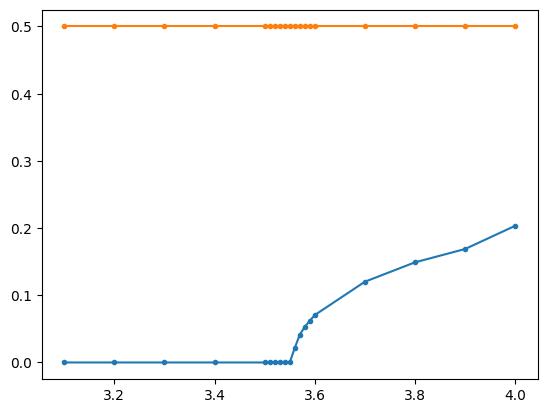

In [4]:
fig, ax = plt.subplots(1)
ax.plot(df['dV'], np.abs(df['mean_Sz']), '.-', c='C0')
ax.plot(df['dV'], np.abs(df['mean_fill']), '.-', c='C1')

In [5]:
# psipm = df[np.isclose(df['dV'], 3.1)]['psi'].iloc[0]
# distrange = 100
# print("correlation legnth = ", psipm.correlation_length2())
# charge_corr_pm = observables.charge_corr(psipm, length=distrange, connected=True)
# charge_corr_pm_w_sign =  psipm.correlation_function("Ntot", "Ntot", [0], distrange)[0] - (psipm.expectation_value("Ntot")[0])**2
# calc_Kc = (np.pi / 2.0) * np.sum(charge_corr_pm_w_sign)
# bosn_Kc ,bosn_Ks = compute_Luttinger_parameter(1, 0.1, 0.8, 0.8 + 2.60)
# plt.plot(charge_corr_pm, label="iDMRG")
# plt.plot(0.07 * np.arange(distrange, dtype=float)**(-2), label=r"$\frac{1}{x^2}$ decay")
# plt.yscale('log')
# plt.xscale('log')
# plt.title(r"Paramagnetic phase ($V_{+-}$ = 2.6), $\chi$=400")
# plt.ylabel(r"$<\rho(x) \rho(0)> - <\rho(0)>^2$")
# plt.xlabel(r"$x$")
# plt.yscale('log')
# plt.xscale('log')
# plt.legend()
# print("computed Kc = ", calc_Kc)
# print("naive bosonization Kc = ", bosn_Kc)
# 0.07 * np.pi**2

In [6]:
# ft = np.array([np.sum(np.exp(2*np.pi*1j * np.arange(distrange) * kint / distrange) * charge_corr_pm_w_sign) for kint in np.arange(distrange)])
# kvals = 2 * np.pi / distrange * np.arange(distrange)
# grads = np.gradient(ft, kvals)
# np.pi * grads[0]

In [7]:
psipm = df[np.isclose(df['dV'], 3.1)]['psi'].iloc[0]
psicrit = df[np.isclose(df['dV'], 3.55)]['psi'].iloc[0]
psifm= df[np.isclose(df['dV'], 4.0)]['psi'].iloc[0]
distrange = 1000
# fmspincorr = observables.SzSz_corr(psifm, length=distrange, connected=True)
# fmchargecorr = observables.charge_corr(psifm, length=distrange, connected=True)
electroncorr = observables.electron_corr(psicrit, length=distrange)
pmelectroncorr = observables.electron_corr(psipm, length=distrange)
fmelectroncorr = observables.electron_corr(psifm, length=distrange)

In [8]:
xicrit, xipm, xifm = psicrit.correlation_length2(), psipm.correlation_length2(), psifm.correlation_length2()
xicrit, xipm, xifm

(np.float64(210.61701842519173),
 np.float64(109.23401045107617),
 np.float64(177.87264157654016))

/tmp/ipykernel_4179293/3128315690.py:27: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax.set_xlim(0,200)


(np.float64(0.7079812002696424), 200)

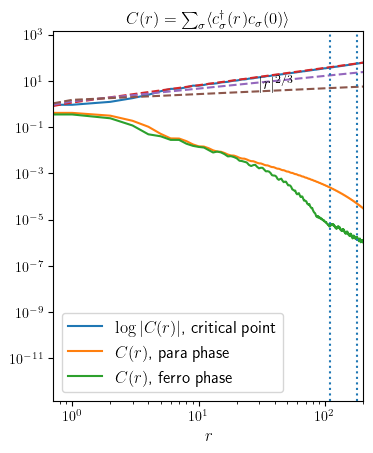

In [22]:
fig, ax = plt.subplots()
fig.set_figwidth(4)
plt.rcParams['text.usetex'] = True
ax.plot(np.abs(np.log(observables.denoise_rolling(np.abs(electroncorr), window=4))), label=r'$\log|C(r)|$, critical point')
ax.plot(np.abs((observables.denoise_rolling(np.abs(pmelectroncorr), window=4))), label=r'$C(r)$, para phase')

ax.plot(np.abs((observables.denoise_rolling(np.abs(fmelectroncorr), window=4))), label=r'$C(r)$, ferro phase')

ax.plot(1.15*np.arange(distrange)**(0.75), ls='--')
ax.text(30, 5, r'$|r|^{2/3}$', fontsize=12)
# plt.plot(0.025 * (np.arange(distrange)[1:])**-1.65)


ax.plot(1.3*np.arange(distrange)**(0.55), ls='--')

ax.plot(1.5*np.arange(distrange)**(1./4.), ls='--')
ax.legend(loc='lower left', fontsize=12)
ax.set_xlabel(r'$r$', fontsize=12)
ax.set_title(r"$C(r) = \sum_{\sigma}\langle c^\dagger_\sigma(r) c_\sigma(0) \rangle$", fontsize=12)

ax.axvline(xicrit ,ls=':')
ax.axvline(xipm ,ls=':')
ax.axvline(xifm ,ls=':')

ax.set_yscale('log')
ax.set_xscale('log')
ax.set_xlim(0,200)
# ax.set_ylim(1e-1, 1e2)
# fig.savefig('showstretchedExp.pdf', bbox_inches='tight')

In [23]:
pm_pmcorr = observables.SpSm_corr(psipm, distrange)
crit_pmcorr = observables.SpSm_corr(psicrit, distrange)
fm_pmcorr = observables.SpSm_corr(psifm, distrange)

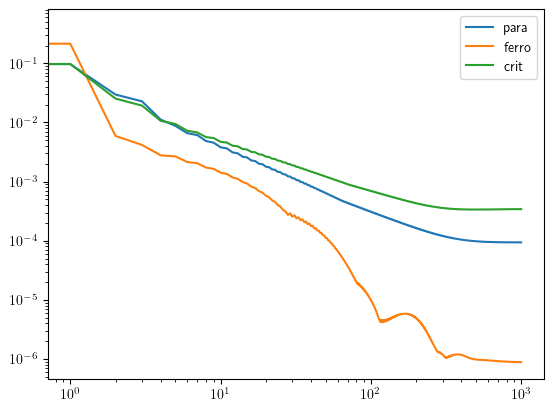

In [24]:
xvals = np.arange(distrange)
plt.plot(xvals, observables.denoise_rolling(np.abs(pm_pmcorr), window=2), label='para')
plt.plot(xvals, observables.denoise_rolling(np.abs(fm_pmcorr), window=2), label='ferro')
plt.plot(xvals, observables.denoise_rolling(np.abs(crit_pmcorr), window=2), label='crit')
# plt.plot(xvals, xvals**)
plt.yscale('log')
plt.xscale('log')
plt.legend()

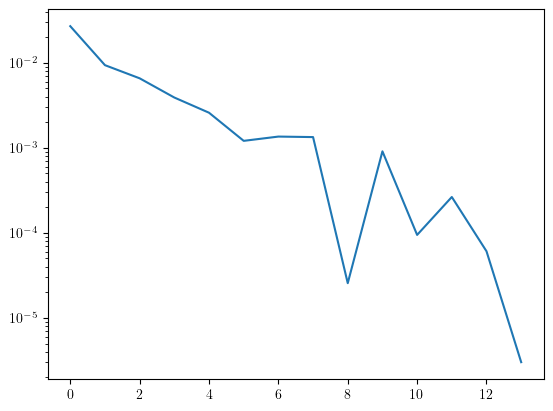

In [30]:
plt.plot(np.abs(df[np.isclose(df['dV'], 3.1)]['diagnostics'].iloc[0]['Delta_S']))
plt.yscale('log')